In [53]:
import torch

target_shape = [32,64]
target_extent = [1.0,1.0,0,-1.0]  # x_max, y_max, x_min, y_min
target_interval = [-1,1]
normalize_to_interval = True
target_dtype = torch.float32

In [54]:
def from_realistic_world(hm: torch.Tensor, extent: tuple[float, float, float, float]) -> torch.Tensor:
    """
    Process heightmap from realistic world to match training observation format.
    The heightmap is expected to be in the same local coordinate frame as the robot (i.e., centered around the robot's position).
    Increasing row index -> decreasing X coordinate (backward from robot's perspective)
    Increasing column index -> decreasing Y coordinate (right from robot's perspective)
    Args:
        hm (torch.Tensor): Heightmap tensor from realistic world (H, W)
        extent (tuple): Extent of the heightmap in the format (x_min, y_min, x_max, y_max)
    """
    # check if the extent contains the percep_extent
    if (
        extent[0] < target_extent[0]
        or extent[1] < target_extent[1]
        or extent[2] > target_extent[2]
        or extent[3] > target_extent[3]
    ):
        raise ValueError("The provided extent does not fully contain the percep_extent.")
    # construct sampling grid
    x_target = torch.linspace(target_extent[0], target_extent[2], target_shape[0], device=hm.device)
    y_target = torch.linspace(target_extent[1], target_extent[3], target_shape[1], device=hm.device)
    px, py = torch.meshgrid(x_target, y_target, indexing="ij")
    grid_v = 2 * (px - extent[0]) / (extent[2] - extent[0]) - 1
    grid_u = 2 * (py - extent[1]) / (extent[3] - extent[1]) - 1
    grid = torch.stack((grid_u, grid_v), dim=-1)  # (H_p, W_p, 2)
    # Add batch dimensions
    grid = grid.unsqueeze(0)  # (1, H_p, W_p, 2)
    hm_input = hm.unsqueeze(0).unsqueeze(0)  # (1, 1, H_src, W_src)
    z_coords = torch.nn.functional.grid_sample(
        hm_input,
        grid,  # (1, H_percep, W_percep, 2)
        mode="bilinear",
        padding_mode="border",
        align_corners=True,
    )
    z_coords.clamp_(target_interval[0], target_interval[1])
    # Normalize to interval if specified
    if normalize_to_interval:
        z_coords.div_(target_interval[1] - target_interval[0])
    return z_coords.squeeze(0).to(target_dtype)  # (1, H_percep, W_percep)

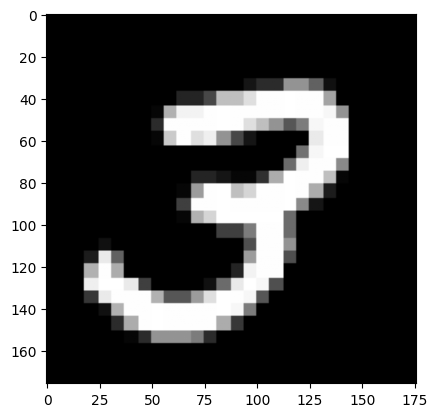

In [55]:
import cv2
import matplotlib.pyplot as plt

im = cv2.imread("/Users/davidkorcak/Downloads/images.png", cv2.IMREAD_GRAYSCALE)
im_tensor = torch.from_numpy(im).float() / 255.0  # Normalize to
im_extent = [1.,1.,-1,-1]  # x_max, y_max, x_min, y_min
plt.imshow(im_tensor, cmap='gray')

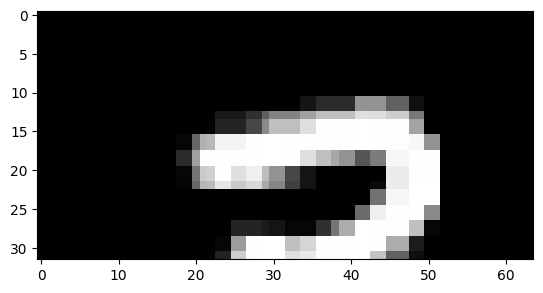

In [56]:
processed_hm = from_realistic_world(im_tensor, im_extent)
plt.imshow(processed_hm.squeeze(0), cmap='gray')